# Pipeline v2 — Boosting models and ranking-style evaluation

This notebook uses **`data/processed/df_model_v2.csv`**, produced by `python scripts/build_processed_datasets.py --pipeline-version 2`. That table is the v1 feature path plus additional listening-window metrics (10/30-day slices, `completion_ratio`, interaction flags, and a calibration-based usage split for some binaries—see `src/pipeline_v2.py`).

**Models.** We keep a strong **Random Forest** and **LightGBM** as references from iteration 06, add **histogram gradient boosting** (`HistGradientBoostingClassifier`) for a scalable sklearn boosting baseline, and **`GradientBoostingClassifier`** on a stratified training subsample—full training rows make classic GBC prohibitively slow on ~780k samples, but the subsample keeps class balance honest and still yields a valid out-of-sample comparison on the fixed validation split.

**Metrics.** ROC AUC remains the headline ranker, but for rare churn (~9%) **average precision** and the **precision–recall (PR) curve** track minority-class performance more directly than ROC. **Recall@K** (share of all validation churners captured in the top-K highest-risk users) matches how retention teams often work with finite outreach capacity.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from sklearn.model_selection import train_test_split
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

from src.pipeline_v2 import FEATURES_V3 as FEATURE_COLS

try:
    import lightgbm as lgb

    LGBM_AVAILABLE = True
except ImportError:
    LGBM_AVAILABLE = False

try:
    import xgboost as xgb

    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

RANDOM_STATE = 42
DATA_PATH = ROOT / "data" / "processed" / "df_model_v2.csv"

print(f"Project root: {ROOT}")
print(f"Data path exists: {DATA_PATH.is_file()}")
print(f"Feature columns: {len(FEATURE_COLS)}")
print(f"LightGBM: {LGBM_AVAILABLE} | XGBoost: {XGB_AVAILABLE}")

Project root: C:\Users\simon\Desktop\kkbox-ml
Data path exists: True
Feature columns: 44
LightGBM: True | XGBoost: True


## 1. Load data and holdout split

Single stratified **80/20** split, identical random seed to earlier notebooks so results stay comparable in spirit (not a substitute for cross-validation).

In [2]:
df = pd.read_csv(DATA_PATH)
assert set(FEATURE_COLS).issubset(df.columns), "Pipeline v2 columns missing from CSV"

X = df[FEATURE_COLS].copy()
y = df["is_churn"].astype(int)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

n_val = len(y_val)
n_churn_val = int(y_val.sum())
print(f"Train {X_train.shape} | Val {X_val.shape}")
print(f"Validation churn rate: {y_val.mean():.2%} ({n_churn_val:,} users)")

Train (776768, 44) | Val (194192, 44)
Validation churn rate: 8.99% (17,466 users)


## 2. Evaluation utilities

**Recall@K.** Sort users by estimated churn probability (descending). Among the top K, count true churners and divide by total churners in validation → fraction of churn segment you would reach if you could only intervene on K accounts. **Precision@K** is the hit rate in that top list.

K is chosen as absolute counts and as a small fraction of the validation population so the table stays interpretable for campaign sizing.

In [3]:
def proba_positive(model, Xv) -> np.ndarray:
    return model.predict_proba(Xv)[:, 1]


def metrics_block(name: str, y_true, y_proba, threshold: float = 0.5) -> dict:
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "model": name,
        "roc_auc": roc_auc_score(y_true, y_proba),
        "avg_precision": average_precision_score(y_true, y_proba),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


def recall_precision_at_k(y_true: np.ndarray, y_score: np.ndarray, ks: list[int]) -> pd.DataFrame:
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    order = np.argsort(-y_score)
    n_pos = int(y_true.sum())
    rows = []
    n = len(y_true)
    for k in ks:
        kk = min(int(k), n)
        if kk == 0:
            continue
        hits = int(y_true[order[:kk]].sum())
        rows.append(
            {
                "K": kk,
                "recall_at_K": hits / n_pos if n_pos else np.nan,
                "precision_at_K": hits / kk,
            }
        )
    return pd.DataFrame(rows)


def plot_pr_curves(series: dict[str, tuple[np.ndarray, np.ndarray, float]], title: str) -> None:
    fig, ax = plt.subplots(figsize=(7, 5))
    baseline_rate = y_val.mean()
    for label, (prec, rec, ap) in series.items():
        ax.plot(rec, prec, label=f"{label} (AP={ap:.3f})")
    ax.axhline(baseline_rate, color="gray", linestyle="--", linewidth=1, label=f"churn rate ({baseline_rate:.3f})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(title)
    ax.legend(loc="lower left", fontsize=9)
    ax.set_xlim(0, 1.02)
    ax.set_ylim(0, 1.02)
    plt.tight_layout()
    plt.show()


K_LIST = sorted(
    set(
        [
            5_000,
            10_000,
            25_000,
            50_000,
            100_000,
            max(1, n_val // 50),
            max(1, n_val // 20),
            max(1, n_val // 10),
        ]
    )
)

## 3. Fit models

**HistGradientBoostingClassifier** uses binning and is designed for large `n_samples`; **`validation_fraction`** with built-in early stopping avoids hand-tuning iteration counts. **`GradientBoostingClassifier`** is fit on **200k stratified rows** sampled from the training fold (seed fixed); validation metrics are still computed on the **full** validation set so comparisons stay on the same 194k users.

**LightGBM** follows the iteration-06 recipe (500 trees, shallow depth, balanced class weight, early stopping on validation log-loss). **XGBoost** runs only when the package is present, with `scale_pos_weight` set from the training class ratio for imbalance.

In [4]:
fitted: dict[str, object] = {}
val_proba: dict[str, np.ndarray] = {}

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
fitted["RF (depth=15, n=200)"] = rf
val_proba["RF (depth=15, n=200)"] = proba_positive(rf, X_val)
print("RF done.")

RF done.


In [5]:
hgb = HistGradientBoostingClassifier(
    learning_rate=0.06,
    max_iter=300,
    max_depth=10,
    min_samples_leaf=50,
    class_weight="balanced",
    early_stopping=True,
    validation_fraction=0.05,
    n_iter_no_change=20,
    random_state=RANDOM_STATE,
)
hgb.fit(X_train, y_train)
fitted["HistGradientBoosting (sklearn)"] = hgb
val_proba["HistGradientBoosting (sklearn)"] = proba_positive(hgb, X_val)
print("HistGradientBoosting done.")

HistGradientBoosting done.


In [6]:
GBC_SUBSAMPLE = 200_000
idx_sub, _ = train_test_split(
    np.arange(len(X_train)),
    train_size=min(GBC_SUBSAMPLE, len(X_train)),
    random_state=RANDOM_STATE,
    stratify=y_train,
)
X_sub = X_train.iloc[idx_sub]
y_sub = y_train.iloc[idx_sub]

gbc = GradientBoostingClassifier(
    n_estimators=120,
    learning_rate=0.08,
    max_depth=4,
    subsample=0.5,
    random_state=RANDOM_STATE,
)
gbc.fit(X_sub, y_sub)
fitted[f"GradientBoosting (train n={len(X_sub):,})"] = gbc
val_proba[f"GradientBoosting (train n={len(X_sub):,})"] = proba_positive(gbc, X_val)
print(f"GradientBoostingClassifier fit on {len(X_sub):,} stratified train rows.")

GradientBoostingClassifier fit on 200,000 stratified train rows.


In [7]:
if LGBM_AVAILABLE:
    lgbm = lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=31,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )
    lgbm.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=100),
        ],
    )
    fitted["LightGBM"] = lgbm
    val_proba["LightGBM"] = proba_positive(lgbm, X_val)
    print("LightGBM done.")
else:
    print("LightGBM not installed; skipped.")

[100]	valid_0's binary_logloss: 0.521977
[200]	valid_0's binary_logloss: 0.514355
[300]	valid_0's binary_logloss: 0.511419
[400]	valid_0's binary_logloss: 0.509295
[500]	valid_0's binary_logloss: 0.507361
LightGBM done.


In [8]:
if XGB_AVAILABLE:
    ratio = float((y_train == 0).sum() / max(1, (y_train == 1).sum()))
    xgb_clf = xgb.XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=ratio,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric="logloss",
    )
    xgb_clf.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=100,
    )
    fitted["XGBoost"] = xgb_clf
    val_proba["XGBoost"] = proba_positive(xgb_clf, X_val)
    print("XGBoost done.")
else:
    print("XGBoost not installed; skipped (pip install xgboost).")

[0]	validation_0-logloss:0.68325
[100]	validation_0-logloss:0.52018
[200]	validation_0-logloss:0.51208
[300]	validation_0-logloss:0.50804
[399]	validation_0-logloss:0.50490
XGBoost done.


## 4. Scalar metrics (threshold 0.5)

Average precision equals the area under the PR curve and is often a better single number than accuracy under imbalance.

In [9]:
summary = pd.DataFrame(
    [metrics_block(name, y_val, p) for name, p in val_proba.items()]
).sort_values("avg_precision", ascending=False)
display(summary.round(4))

best_name = summary.iloc[0]["model"]
print(f"\nHighest avg precision at 0.5 operating point context: {best_name}")
print(classification_report(
    y_val,
    (val_proba[best_name] >= 0.5).astype(int),
    target_names=["no churn", "churn"],
))

,model,roc_auc,avg_precision,precision,recall,f1
4,XGBoost,0.7791,0.4760,0.2858,0.5757,0.3820
3,LightGBM,0.7793,0.4760,0.2866,0.5757,0.3827
1,HistGradientBoosting (sklearn),0.7786,0.4735,0.2820,0.5791,0.3793
2,"GradientBoosting (train n=200,000)",0.7722,0.4643,0.7775,0.2700,0.4008
0,"RF (depth=15, n=200)",0.7675,0.4534,0.2954,0.5559,0.3858



Highest avg precision at 0.5 operating point context: XGBoost
              precision    recall  f1-score   support

    no churn       0.95      0.86      0.90    176726
       churn       0.29      0.58      0.38     17466

    accuracy                           0.83    194192
   macro avg       0.62      0.72      0.64    194192
weighted avg       0.89      0.83      0.86    194192



## 5. Precision–recall curves

The dashed horizontal line is the churn prevalence. A model adds value when its curve lies clearly above that line for the recall region you care about.

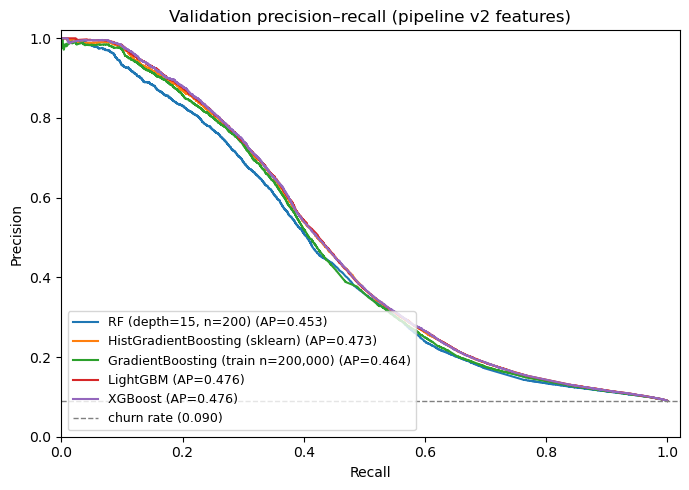

In [10]:
pr_series = {}
for name, p in val_proba.items():
    prec, rec, _ = precision_recall_curve(y_val, p)
    ap = average_precision_score(y_val, p)
    pr_series[name] = (prec, rec, ap)

plot_pr_curves(pr_series, "Validation precision–recall (pipeline v2 features)")

## 6. Recall@K and precision@K

Example: if **recall@50k ≈ 0.45**, contacting the 50k highest-risk validation users captures about 45% of all churners in that split. Use this to tie scores to intervention budget, not as a substitute for proper uplift or causal evaluation.

In [11]:
rk_tables = []
for name, p in val_proba.items():
    rk = recall_precision_at_k(y_val.to_numpy(), p, K_LIST)
    rk.insert(0, "model", name)
    rk_tables.append(rk)
rk_all = pd.concat(rk_tables, ignore_index=True)
display(rk_all.pivot(index="K", columns="model", values="recall_at_K").round(4))

model,"GradientBoosting (train n=200,000)",HistGradientBoosting (sklearn),LightGBM,"RF (depth=15, n=200)",XGBoost
K,,,,,
3883,0.1929,0.1945,0.1960,0.1869,0.1963
5000,0.2341,0.2365,0.2378,0.2287,0.2379
9709,0.3529,0.3557,0.3568,0.3450,0.3563
10000,0.3573,0.3598,0.3615,0.3496,0.3618
19419,0.4565,0.4690,0.4682,0.4612,0.4694
25000,0.5041,0.5103,0.5106,0.5055,0.5109
50000,0.6319,0.6432,0.6435,0.6243,0.6426
100000,0.7972,0.8037,0.8033,0.7861,0.8023


In [12]:
pivot_prec = rk_all.pivot(index="K", columns="model", values="precision_at_K").round(4)
display(pivot_prec)

model,"GradientBoosting (train n=200,000)",HistGradientBoosting (sklearn),LightGBM,"RF (depth=15, n=200)",XGBoost
K,,,,,
3883,0.8676,0.8751,0.8818,0.8406,0.8831
5000,0.8178,0.8262,0.8306,0.7990,0.8312
9709,0.6348,0.6398,0.6418,0.6206,0.6410
10000,0.6241,0.6284,0.6314,0.6106,0.6320
19419,0.4106,0.4218,0.4211,0.4148,0.4222
25000,0.3522,0.3565,0.3568,0.3532,0.3570
50000,0.2207,0.2247,0.2248,0.2181,0.2245
100000,0.1392,0.1404,0.1403,0.1373,0.1401


## 7. Closing notes

- **Classic `GradientBoostingClassifier`** here is intentionally trained on a **subset** of rows; for production-scale boosting on this table size, prefer **LightGBM**, **XGBoost**, or **`HistGradientBoostingClassifier`**.
- **Recall@K** is ranking-based: calibrate K to your operational cap; if you retrain or change the population, recompute baselines.
- A single split understates variance; for reporting, fold PR-AUC / Recall@K or bootstrap confidence bands would be the next tightening step.